<a href="https://colab.research.google.com/github/u2403126-gif/Internship/blob/main/DAY6/Titanic_Survival_predictor/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
df=pd.read_csv("titanic.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
print("Missing values:\n",df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
df=df.drop(columns=['Cabin'])

In [7]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [8]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

In [13]:
df['Embarked'] = df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [14]:
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']]
y = df['Survived']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=38)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
y_pred_log = log_reg.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Survived","Not survived"]))


Logistic Regression Results
Accuracy: 0.832089552238806
              precision    recall  f1-score   support

    Survived       0.82      0.91      0.86       156
Not survived       0.85      0.72      0.78       112

    accuracy                           0.83       268
   macro avg       0.84      0.82      0.82       268
weighted avg       0.83      0.83      0.83       268



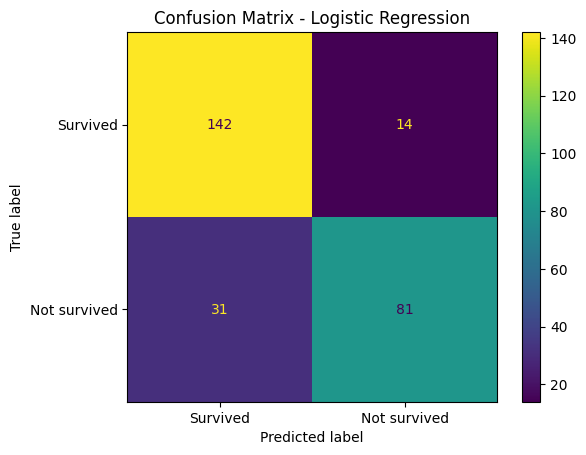

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Not survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [22]:
new_data = [[1, 1, 25, 100.0, 0, 0, 1]]

new_data_df = pd.DataFrame(
    new_data,
    columns=X.columns
)

# Scale input data
new_data_scaled = scaler.transform(new_data_df)

# Predict
prediction = log_reg.predict(new_data_scaled)[0]

if prediction == 1:
    print("Survived")
else:
    print("Not Survived")

Survived


In [23]:
import joblib
joblib.dump(log_reg, "titanic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']